# Open two-level system with multiple observables

This example extends the minimal two-level model with radiative relaxation and pure dephasing. It demonstrates:

- GKSL collapse channels with rates stored separately from their operators;
- a stationary ground-state initial condition;
- a dissipatively broadened third-order rephasing response;
- action detection whose observable optionally applies a fourth projection pulse;
- backward compatibility with an explicit four-interaction pathway;
- instantaneous and time-integrated radiative jump observables.

Natural units are used, with $\hbar=1$. Energies and rates are in eV, while times are in eV$^{-1}$.

In [11]:
from pathlib import Path
import sys

import numpy as np

# Locate the project root when the notebook is launched from examples/
# or from another directory inside the repository.
current_directory = Path.cwd().resolve()
for candidate in (current_directory, *current_directory.parents):
    if (candidate / "projet_solver10" / "__init__.py").is_file():
        project_root = str(candidate)
        if project_root not in sys.path:
            sys.path.insert(0, project_root)
        break
else:
    raise RuntimeError("Could not locate the directory containing projet_solver10.")

from projet_solver10 import (
    EigenbasisKModel,
    ObservableSpec,
    SpectroscopyPlotter,
    SpectroscopySolver,
)
from projet_solver10.pathways import FrequencyPathway
from projet_solver10.protocols import (
    PropagationInterval,
    SpectroscopyProtocol,
    standard_nq_protocol,
)

## 1. Physical model

The basis is ordered as $\{|g\rangle, |e\rangle\}$. The Hamiltonian and transition operator are

$$
H = \omega_{eg}|e\rangle\langle e|,
\qquad
J = \mu\left(|e\rangle\langle g|+|g\rangle\langle e|\right).
$$

Radiative relaxation uses $C_{\mathrm{rad}}=|g\rangle\langle e|$. Pure dephasing uses $C_\phi=\sigma_z$. Because $\mathcal D[\sigma_z]\rho_{eg}=-2\rho_{eg}$, the collapse-channel rate is set to $\Gamma_\phi/2$ so that the optical coherence decays at the requested pure-dephasing rate $\Gamma_\phi$.

In [12]:
# Model parameters
omega_eg = 2.0
dipole_strength = 0.5
gamma_radiative = 0.04
gamma_pure_dephasing = 0.03

# Bare matrices in the |g>, |e> basis
H_site = np.array(
    [[0.0, 0.0],
     [0.0, omega_eg]],
    dtype=complex,
)
interaction_site = dipole_strength * np.array(
    [[0.0, 1.0],
     [1.0, 0.0]],
    dtype=complex,
)

ground_population_op = np.array([[1.0, 0.0], [0.0, 0.0]], dtype=complex)
excited_population_op = np.array([[0.0, 0.0], [0.0, 1.0]], dtype=complex)
radiative_lowering = np.array([[0.0, 1.0], [0.0, 0.0]], dtype=complex)
dephasing_operator = np.array([[-1.0, 0.0], [0.0, 1.0]], dtype=complex)

print("Hamiltonian:\n", H_site)
print("Interaction operator:\n", interaction_site)
print("Radiative collapse operator:\n", radiative_lowering)

Hamiltonian:
 [[0.+0.j 0.+0.j]
 [0.+0.j 2.+0.j]]
Interaction operator:
 [[0. +0.j 0.5+0.j]
 [0.5+0.j 0. +0.j]]
Radiative collapse operator:
 [[0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j]]


## 2. Build the model and solver

`c_ops_raw` contains `(operator, rate)` pairs. The rate must not be folded into the operator. `EigenbasisKModel` names these channels according to their input order, so `c_op_0` is radiative relaxation and `c_op_1` is pure dephasing in this example.

In [13]:
model = EigenbasisKModel(
    H_site,
    interaction_site,
    c_ops_raw=(
        (radiative_lowering, gamma_radiative),
        (dephasing_operator, gamma_pure_dephasing / 2.0),
    ),
    observable_op_arrays={
        "polarization": interaction_site,
        "ground_population": ground_population_op,
        "excited_population": excited_population_op,
    },
)

solver = SpectroscopySolver(backend="dense", eta=0.002)
solver.feed_model(model)

print(solver.summary())
print("Jump channels:", solver.jump_channel_names())
print("Memory estimate:", solver.estimate_memory())

{'backend': 'dense_liouville', 'backend_capabilities': {'pure_state': True, 'mixed_state': True, 'time_domain': True, 'frequency_domain': True, 'hilbert_resolvent': True, 'lindblad': True, 'finite_temperature': True, 'coupled_sectors': True, 'matrix_free': False, 'low_rank': False, 'metadata': {}}, 'backend_support': {'state_kinds': ('pure', 'mixed'), 'supported_pairs': (('unitary', 'time'), ('unitary', 'frequency'), ('lindblad', 'time'), ('lindblad', 'frequency')), 'exactness': 'exact', 'matrix_free': False, 'low_rank': False, 'stationary_mode_deflation': False}, 'model_requirements': {'state_kind': 'mixed', 'generator_kind': 'lindblad', 'domains': ('time', 'frequency'), 'exactness': 'exact', 'matrix_free_required': False, 'stationary_mode_deflation_required': False, 'metadata': {}}, 'model_capabilities': {'pure_state': True, 'mixed_state': False, 'time_domain': True, 'frequency_domain': False, 'hilbert_resolvent': False, 'lindblad': False, 'finite_temperature': False, 'coupled_sector

## 3. Verify the stationary initial state

At zero temperature, the supplied ground state should satisfy $\mathcal L_{\mathrm{eff}}\rho_g=0$. This check also verifies that the collapse channels are compatible with the claimed initial state.

In [14]:
rho_ground = ground_population_op.copy()
rho_ground_vector = rho_ground.reshape(-1, order="F")
stationarity_residual = np.linalg.norm(
    solver.backend.generator.matvec(rho_ground_vector)
)

print(f"Stationarity residual: {stationarity_residual:.3e}")
assert stationarity_residual < 1e-12

Stationarity residual: 0.000e+00


## 4. Dissipatively broadened third-order rephasing response

For a two-level system, the rephasing $\chi^{(3)}$ signal contains the ground-state-bleach and stimulated-emission pathways

$$R_1=(B_u,K_u,B_d),\qquad R_2=(B_u,B_d,K_u).$$

Both pathways carry the coherence history $q=(-1,0,+1)$. There is no excited-state-absorption pathway because the model contains no doubly excited manifold. Radiative relaxation contributes $\Gamma_1/2$ to the optical-coherence decay, while pure dephasing contributes $\Gamma_\phi$.

In [15]:
pathway_r1 = FrequencyPathway(
    name="R1",
    interactions=("Bu", "Ku", "Bd"),
    component="rephasing",
    detection="polarization",
)
pathway_r2 = FrequencyPathway(
    name="R2",
    interactions=("Bu", "Bd", "Ku"),
    component="rephasing",
    detection="polarization",
)
protocol_1q = standard_nq_protocol(
    order=1,
    nq_interval=1,
    detection_interval=3,
    n_interactions=3,
    nq_axis="omega_1q",
    detection_axis="omega_emit",
)
omega_1q = np.linspace(-2.5, -1.5, 101)
omega_emit = np.linspace(1.5, 2.5, 101)
population_waiting_time = 10.0

rephasing_result = solver.generate_spectrum(
    protocol_1q,
    axes={"omega_1q": omega_1q, "omega_emit": omega_emit},
    fixed_coordinates={"t2": population_waiting_time},
    pathways=(pathway_r1, pathway_r2),
)
rephasing_signal = rephasing_result.components["rephasing"]

assert pathway_r1.coherence_orders == (-1, 0, 1)
assert pathway_r2.coherence_orders == (-1, 0, 1)
assert np.all(np.isfinite(rephasing_signal))
assert np.max(np.abs(rephasing_signal)) > 0.0

peak_index = np.unravel_index(
    np.argmax(np.abs(rephasing_signal)), rephasing_signal.shape
)
print("Strongest rephasing coordinate:")
print(f"  omega_1q   = {omega_1q[peak_index[0]]:.4f} eV")
print(f"  omega_emit = {omega_emit[peak_index[1]]:.4f} eV")

Strongest rephasing coordinate:
  omega_1q   = -2.0000 eV
  omega_emit = 2.0000 eV


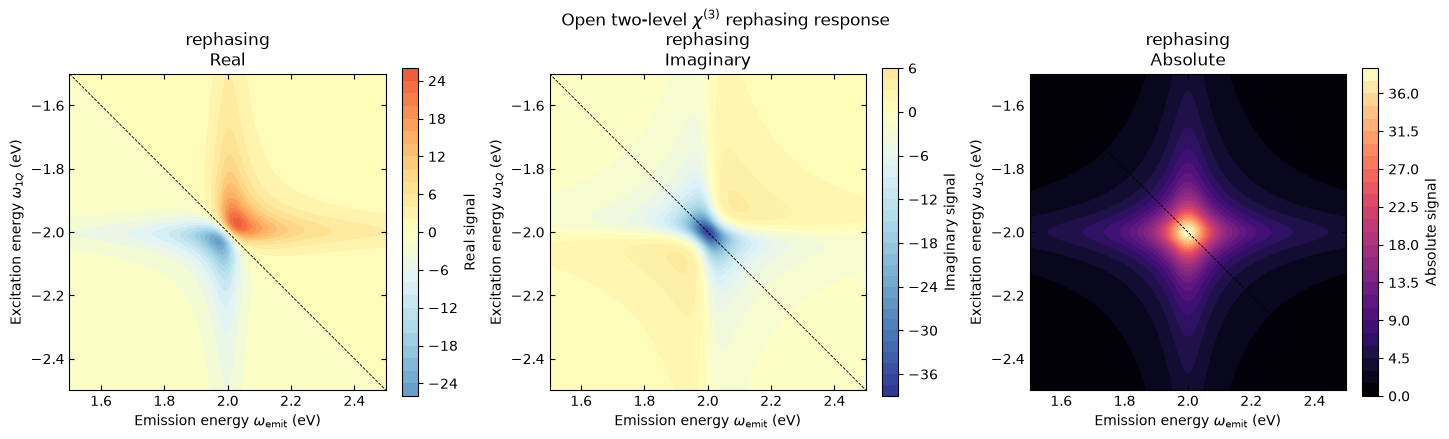

PlotResult(figure=<Figure size 1440x420 with 6 Axes>, axes=array([[<Axes: title={'center': 'rephasing\nReal'}, xlabel='Emission energy $\\omega_{\\mathrm{emit}}$ (eV)', ylabel='Excitation energy $\\omega_{1Q}$ (eV)'>,
        <Axes: title={'center': 'rephasing\nImaginary'}, xlabel='Emission energy $\\omega_{\\mathrm{emit}}$ (eV)', ylabel='Excitation energy $\\omega_{1Q}$ (eV)'>,
        <Axes: title={'center': 'rephasing\nAbsolute'}, xlabel='Emission energy $\\omega_{\\mathrm{emit}}$ (eV)', ylabel='Excitation energy $\\omega_{1Q}$ (eV)'>]],
      dtype=object), panel_names=('rephasing',), data={'rephasing': {'real': array([[-8.50078088e-02, -8.75891467e-02, -9.03123801e-02, ...,
        -1.84310980e-03, -8.84738855e-04,  3.46944695e-18],
       [-8.75891467e-02, -9.02396611e-02, -9.30356134e-02, ...,
        -9.59130035e-04,  3.46944695e-18,  8.84738855e-04],
       [-9.03123801e-02, -9.30356134e-02, -9.59080002e-02, ...,
         0.00000000e+00,  9.59130035e-04,  1.84310980e-03],
    

In [16]:
plotter = SpectroscopyPlotter(detection_phase=0.0)
plotter.plot_spectrum_result(
    rephasing_result,
    params={
        "source": "components",
        "names": ["rephasing"],
        "view": "all",
        "normalization": "row",
        "title": r"Open two-level $\chi^{(3)}$ rephasing response",
        "labels": (
            r"Emission energy $\omega_{\mathrm{emit}}$ (eV)",
            r"Excitation energy $\omega_{1Q}$ (eV)",
        ),
        "diagonals": "auto",
        "style": {
            "cmap": "RdYlBu_r",
            "abs_cmap": "magma",
            "levels": 30,
            "contour_lines": False,
        },
        "show": True,
    },
)

## 5. Action detection from the shared three-pulse response

The solver first propagates the same three field interactions used for the third-order rephasing polarization. Polarization is contracted directly from that response, whereas each action observable carries an optional fourth interaction that projects the final optical coherence onto the population sector $q=0$. The common three-pulse response is therefore propagated only once and then reused by the coherent and action-detection branches.

For both rephasing pathways, the projection interaction is `Bu`, which changes the final order $q=+1$ to $q=0$. Explicit four-interaction pathways are also retained below to verify backward compatibility and numerical equivalence.

In [17]:
action_pathway_r1 = FrequencyPathway(
    name="A-R1",
    interactions=[
        {"label": "Bu", "pulse_index": 0},
        {"label": "Ku", "pulse_index": 1},
        {"label": "Bd", "pulse_index": 2},
        {"label": "Bu", "pulse_index": 3},
    ],
    component="action_rephasing",
    detection="excited_population",
)
action_pathway_r2 = FrequencyPathway(
    name="A-R2",
    interactions=[
        {"label": "Bu", "pulse_index": 0},
        {"label": "Bd", "pulse_index": 1},
        {"label": "Ku", "pulse_index": 2},
        {"label": "Bu", "pulse_index": 3},
    ],
    component="action_rephasing",
    detection="excited_population",
)
action_protocol = standard_nq_protocol(
    order=1,
    nq_interval=1,
    detection_interval=3,
    n_interactions=4,
    nq_axis="omega_1q",
    detection_axis="omega_3",
)

solver.set_pathways([pathway_r1, pathway_r2, action_pathway_r1, action_pathway_r2])
print("Action-pathway coherence orders:")
print("  A-R1:", action_pathway_r1.coherence_orders)
print("  A-R2:", action_pathway_r2.coherence_orders)

Population-pathway coherence orders: (1, 0)


In [18]:
radiative_channel = solver.jump_channel_names()[0]
integration_window = 5.0 / gamma_radiative

shared_observables = {
    "polarization": "polarization",
    "action_ground_population": ObservableSpec.action(
        "action_ground_population",
        fourth_interaction="Bu",
        operator="ground_population",
    ),
    "action_excited_population": ObservableSpec.action(
        "action_excited_population",
        fourth_interaction="Bu",
        operator="excited_population",
    ),
    "action_radiative_rate": ObservableSpec.action(
        "action_radiative_rate",
        fourth_interaction="Bu",
        kind="jump_rate",
        channel=radiative_channel,
    ),
    "action_integrated_fluorescence": ObservableSpec.mean_jump(
        "action_integrated_fluorescence",
        radiative_channel,
        time_window=(0.0, integration_window),
        efficiency=1.0,
        n_steps=101,
        fourth_interaction="Bu",
    ),
}

action_omega_1q = np.linspace(-2.5, -1.5, 41)
action_omega_3 = np.linspace(1.5, 2.5, 41)
shared_result = solver.generate_spectrum(
    protocol_1q,
    {"omega_1q": action_omega_1q, "omega_emit": action_omega_3},
    fixed_coordinates={"t2": population_waiting_time},
    pathways=[pathway_r1, pathway_r2],
    observables=shared_observables,
)

legacy_observables = {
    "ground_population": "ground_population",
    "excited_population": "excited_population",
    "radiative_rate": {
        "kind": "jump_rate",
        "channel": radiative_channel,
    },
    "integrated_fluorescence": ObservableSpec.mean_jump(
        "integrated_fluorescence",
        radiative_channel,
        time_window=(0.0, integration_window),
        n_steps=101,
    ),
}
action_result = solver.generate_spectrum(
    action_protocol,
    {"omega_1q": action_omega_1q, "omega_3": action_omega_3},
    fixed_coordinates={"t2": population_waiting_time, "t4": 0.0},
    pathways=[action_pathway_r1, action_pathway_r2],
    observables=legacy_observables,
)

## 6. Compare projected observables with explicit four-pulse pathways

The polarization and action signals in `shared_result` originate from the same three-pulse propagation. Only the action observables apply `Bu` before detection. The explicit four-pulse calculation in `action_result` provides the historical formulation of the same signal.

The following checks compare the two formulations point by point for both rephasing pathways. The integrated fluorescence is evaluated over a finite window after the projection pulse.

In [19]:
pathway_pairs = [("R1", "A-R1"), ("R2", "A-R2")]

for shared_name, explicit_name in pathway_pairs:
    polarization = shared_result.observables["polarization"][shared_name]
    action_population = shared_result.observables["action_excited_population"][shared_name]
    action_rate = shared_result.observables["action_radiative_rate"][shared_name]
    action_fluorescence = shared_result.observables["action_integrated_fluorescence"][shared_name]

    assert np.max(np.abs(polarization)) > 0.0
    assert np.max(np.abs(action_population)) > 0.0
    np.testing.assert_allclose(
        action_population,
        action_result.observables["excited_population"][explicit_name],
        rtol=1e-11, atol=1e-12,
    )
    np.testing.assert_allclose(
        action_rate,
        action_result.observables["radiative_rate"][explicit_name],
        rtol=1e-11, atol=1e-12,
    )
    np.testing.assert_allclose(
        action_fluorescence,
        action_result.observables["integrated_fluorescence"][explicit_name],
        rtol=1e-11, atol=1e-12,
    )
    print(f"{shared_name}: max polarization = {np.max(np.abs(polarization)):.6e}")
    print(f"{shared_name}: max action population = {np.max(np.abs(action_population)):.6e}")

print("Optional projection and explicit four-pulse pathways agree.")

Initial excited contribution: 0.250000
Initial radiative rate:       0.010000
Integrated fluorescence:     0.248367
Analytic finite-window yield:    0.993262
Trapezoidal finite-window yield: 0.993469
All open-system validation checks passed.


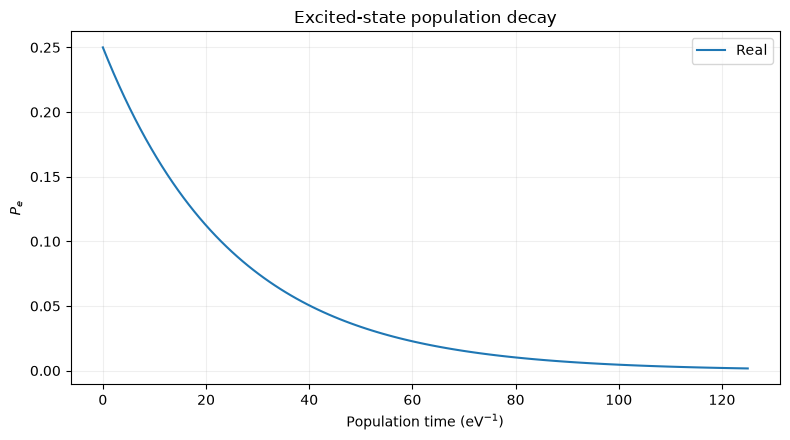

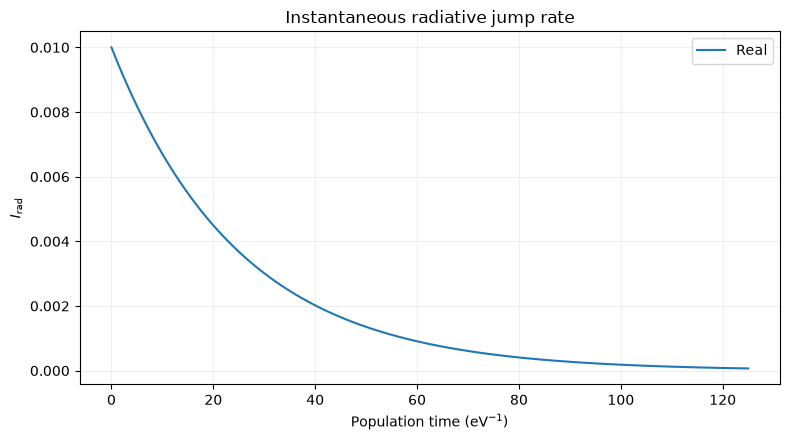

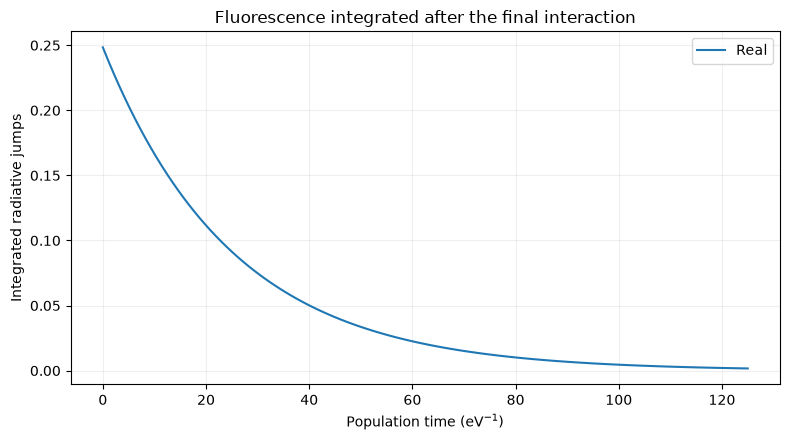

PlotResult(figure=<Figure size 800x450 with 1 Axes>, axes=array([[<Axes: title={'center': 'Fluorescence integrated after the final interaction'}, xlabel='Population time (eV$^{-1}$)', ylabel='Integrated radiative jumps'>]],
      dtype=object), panel_names=('real',), data={'real': array([0.24836724, 0.23823124, 0.2285089 , 0.21918332, 0.21023833,
       0.20165839, 0.1934286 , 0.18553468, 0.17796291, 0.17070014,
       0.16373378, 0.15705171, 0.15064235, 0.14449455, 0.13859765,
       0.13294141, 0.12751599, 0.122312  , 0.11732038, 0.11253247,
       0.10793996, 0.10353487, 0.09930956, 0.09525668, 0.0913692 ,
       0.08764038, 0.08406372, 0.08063304, 0.07734236, 0.07418598,
       0.07115841, 0.06825439, 0.06546889, 0.06279707, 0.06023429,
       0.0577761 , 0.05541822, 0.05315658, 0.05098723, 0.04890641,
       0.04691051, 0.04499607, 0.04315976, 0.04139838, 0.03970889,
       0.03808835, 0.03653394, 0.03504297, 0.03361285, 0.03224109,
       0.03092532, 0.02966324, 0.02845266, 0.027

In [20]:
"""
    excited_population.astype(complex),
    w=times,
    params={
        "view": "real",
        "title": "Excited-state population decay",
        "xlabel": r"Population time (eV$^{-1}$)",
        "ylabel": r"$P_e$",
        "show": True,
    },
)

plotter.plot_1d(
    radiative_rate.astype(complex),
    w=times,
    params={
        "view": "real",
        "title": "Instantaneous radiative jump rate",
        "xlabel": r"Population time (eV$^{-1}$)",
        "ylabel": r"$I_{\mathrm{rad}}$",
        "show": True,
    },
)

plotter.plot_1d(
    integrated_fluorescence.astype(complex),
    w=times,
    params={
        "view": "real",
        "title": "Fluorescence integrated after the final interaction",
        "xlabel": r"Population time (eV$^{-1}$)",
        "ylabel": "Integrated radiative jumps",
        "show": True,
    },
"""

## What this example shows

1. Collapse operators and rates are supplied separately.
2. The ground state is stationary under the field-free GKSL generator.
3. Radiative relaxation and pure dephasing broaden a third-order rephasing spectrum.
4. An action observable can carry the fourth projection pulse while the pathway itself remains third order.
5. The same three-pulse response is reused for polarization, population, instantaneous jump rate, and integrated fluorescence.
6. Explicit four-interaction pathways remain supported and give the same action signal.